-----------------------------
## Practice Hands-on case study: Linear Regression

-----------------------------

Welcome to the Hands-on case study on Linear Regression. In this case study, we aim to construct a linear model that explains the relationship a car's mileage (mpg) has with its other attributes

-----------------------------
## Dataset: 
-----------------------------
There are 8 variables in the data: 

- mpg: miles per gallon
- cyl: number of cylinders
- disp: engine displacement (cu. inches) or engine size
- hp: horsepower
- wt: vehicle weight (lbs.)
- acc: time taken to accelerate from O to 60 mph (sec.)
- yr: model year
- car name: car model name


- Also provided are the car labels (types) 
- Missing data values are marked by series of question marks.

## Import Libraries

In [1]:
import numpy as np   
import pandas as pd    
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns

/var/folders/wy/bkmn6g6d7l70zk01gf49xkl00000gn/T/ipykernel_6168/3121756483.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Load and review data

In [3]:
data = pd.read_csv("../data/auto-mpg.csv")  
data.shape

(398, 8)

In [7]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


In [8]:
#dropping/ignoring car_name 
#data = data.drop('car name', axis=1)
# Also replacing the categorical var with actual values
#data['origin'] = data['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


## Create Dummy Variables
Values like 'america' cannot be read into an equation. Using substitutes like 1 for america, 2 for europe and 3 for asia would end up implying that european cars fall exactly half way between american and asian cars! we dont want to impose such an baseless assumption!

So we create 3 simple true or false columns with titles equivalent to "Is this car America?", "Is this care European?" and "Is this car Asian?". These will be used as independent variables without imposing any kind of ordering between the three regions.




In [10]:
#data = pd.get_dummies(data, columns=['origin'])
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


## Dealing with Missing Values

In [11]:
#A quick summary of the data columns
data.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [12]:
# hp is missing cause it does not seem to be reqcognized as a numerical column!
data.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
dtype: object

In [ ]:
# which method of string checks whether a column is a number
#data['horsepower'].str.isnumeric()

# which method of string checks whether a column is a number or missing
data['horsepower'].str.isnumeric() 
data['horsepower'].isnull()

### Q.2 The method  used to check whether an entry of a column is a numerical value or is it missing?


In [22]:
 # if the string is made of digits store True else False hint: use isdigit() 
hpIsDigit = pd.DataFrame(data.horsepower.str.isnumeric()) 


data[hpIsDigit['horsepower'] == False]   # from temp take only those rows where hp has false


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4,98.0,?,2046,19.0,71
126,21.0,6,200.0,?,2875,17.0,74
330,40.9,4,85.0,?,1835,17.3,80
336,23.6,4,140.0,?,2905,14.3,80
354,34.5,4,100.0,?,2320,15.8,81
374,23.0,4,151.0,?,3035,20.5,82


In [73]:
# Missing values have a'?''
# Replace missing values with NaN
data = data.replace('?', np.nan)
data[hpIsDigit['horsepower'] == False] 

data.horsepower
data['horsepower'].isnull().count

<bound method Series.count of 0      False
1      False
2      False
3      False
4      False
       ...  
393    False
394    False
395    False
396    False
397    False
Name: horsepower, Length: 398, dtype: bool>

There are various ways to handle missing values. Drop the rows, replace missing values with median values etc. of the 398 rows 6 have NAN in the hp column. We could drop those 6 rows - which might not be a good idea under all situations


In [74]:
#instead of dropping the rows, lets replace the missing values with median value. 
# First convert horsepower to numeric type, coercing errors to NaN
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
data.median()

mpg               23.0
cylinders          4.0
displacement     148.5
horsepower        93.5
weight          2803.5
acceleration      15.5
model year        76.0
dtype: float64

### Filling the missing values with median value

In [75]:
# replace the missing values with median value.
# Note, we do not need to specify the column names below
# every column's missing value is replaced with that column's median respectively  (axis =0 means columnwise)

medianFiller = lambda x: x.fillna(x.median())
data = data.apply(medianFiller,axis=0)



data['horsepower'] = data['horsepower'].astype('float64')  # converting the hp column from object / string type to float
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,398.000,398.000,398.000,398.000,398.000,398.000,398.000
mean,23.515,5.455,193.426,104.304,2970.425,15.568,76.010
std,7.816,1.701,104.270,38.223,846.842,2.758,3.698
min,9.000,3.000,68.000,46.000,1613.000,8.000,70.000
25%,17.500,4.000,104.250,76.000,2223.750,13.825,73.000
50%,23.000,4.000,148.500,93.500,2803.500,15.500,76.000
75%,29.000,8.000,262.000,125.000,3608.000,17.175,79.000
max,46.600,8.000,455.000,230.000,5140.000,24.800,82.000


## BiVariate Plots

A bivariate analysis among the different variables can be done using scatter matrix plot. Seaborn libs create a dashboard reflecting useful information about the dimensions. The result can be stored as a .png file. 

In [31]:
data_attr = data.iloc[:, 0:7]
sns.pairplot(data_attr, diag_kind='kde')   # to plot density curve instead of histogram on the diag

/opt/anaconda3/envs/fixed_env/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/fixed_env/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/fixed_env/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/fixed_env/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will be

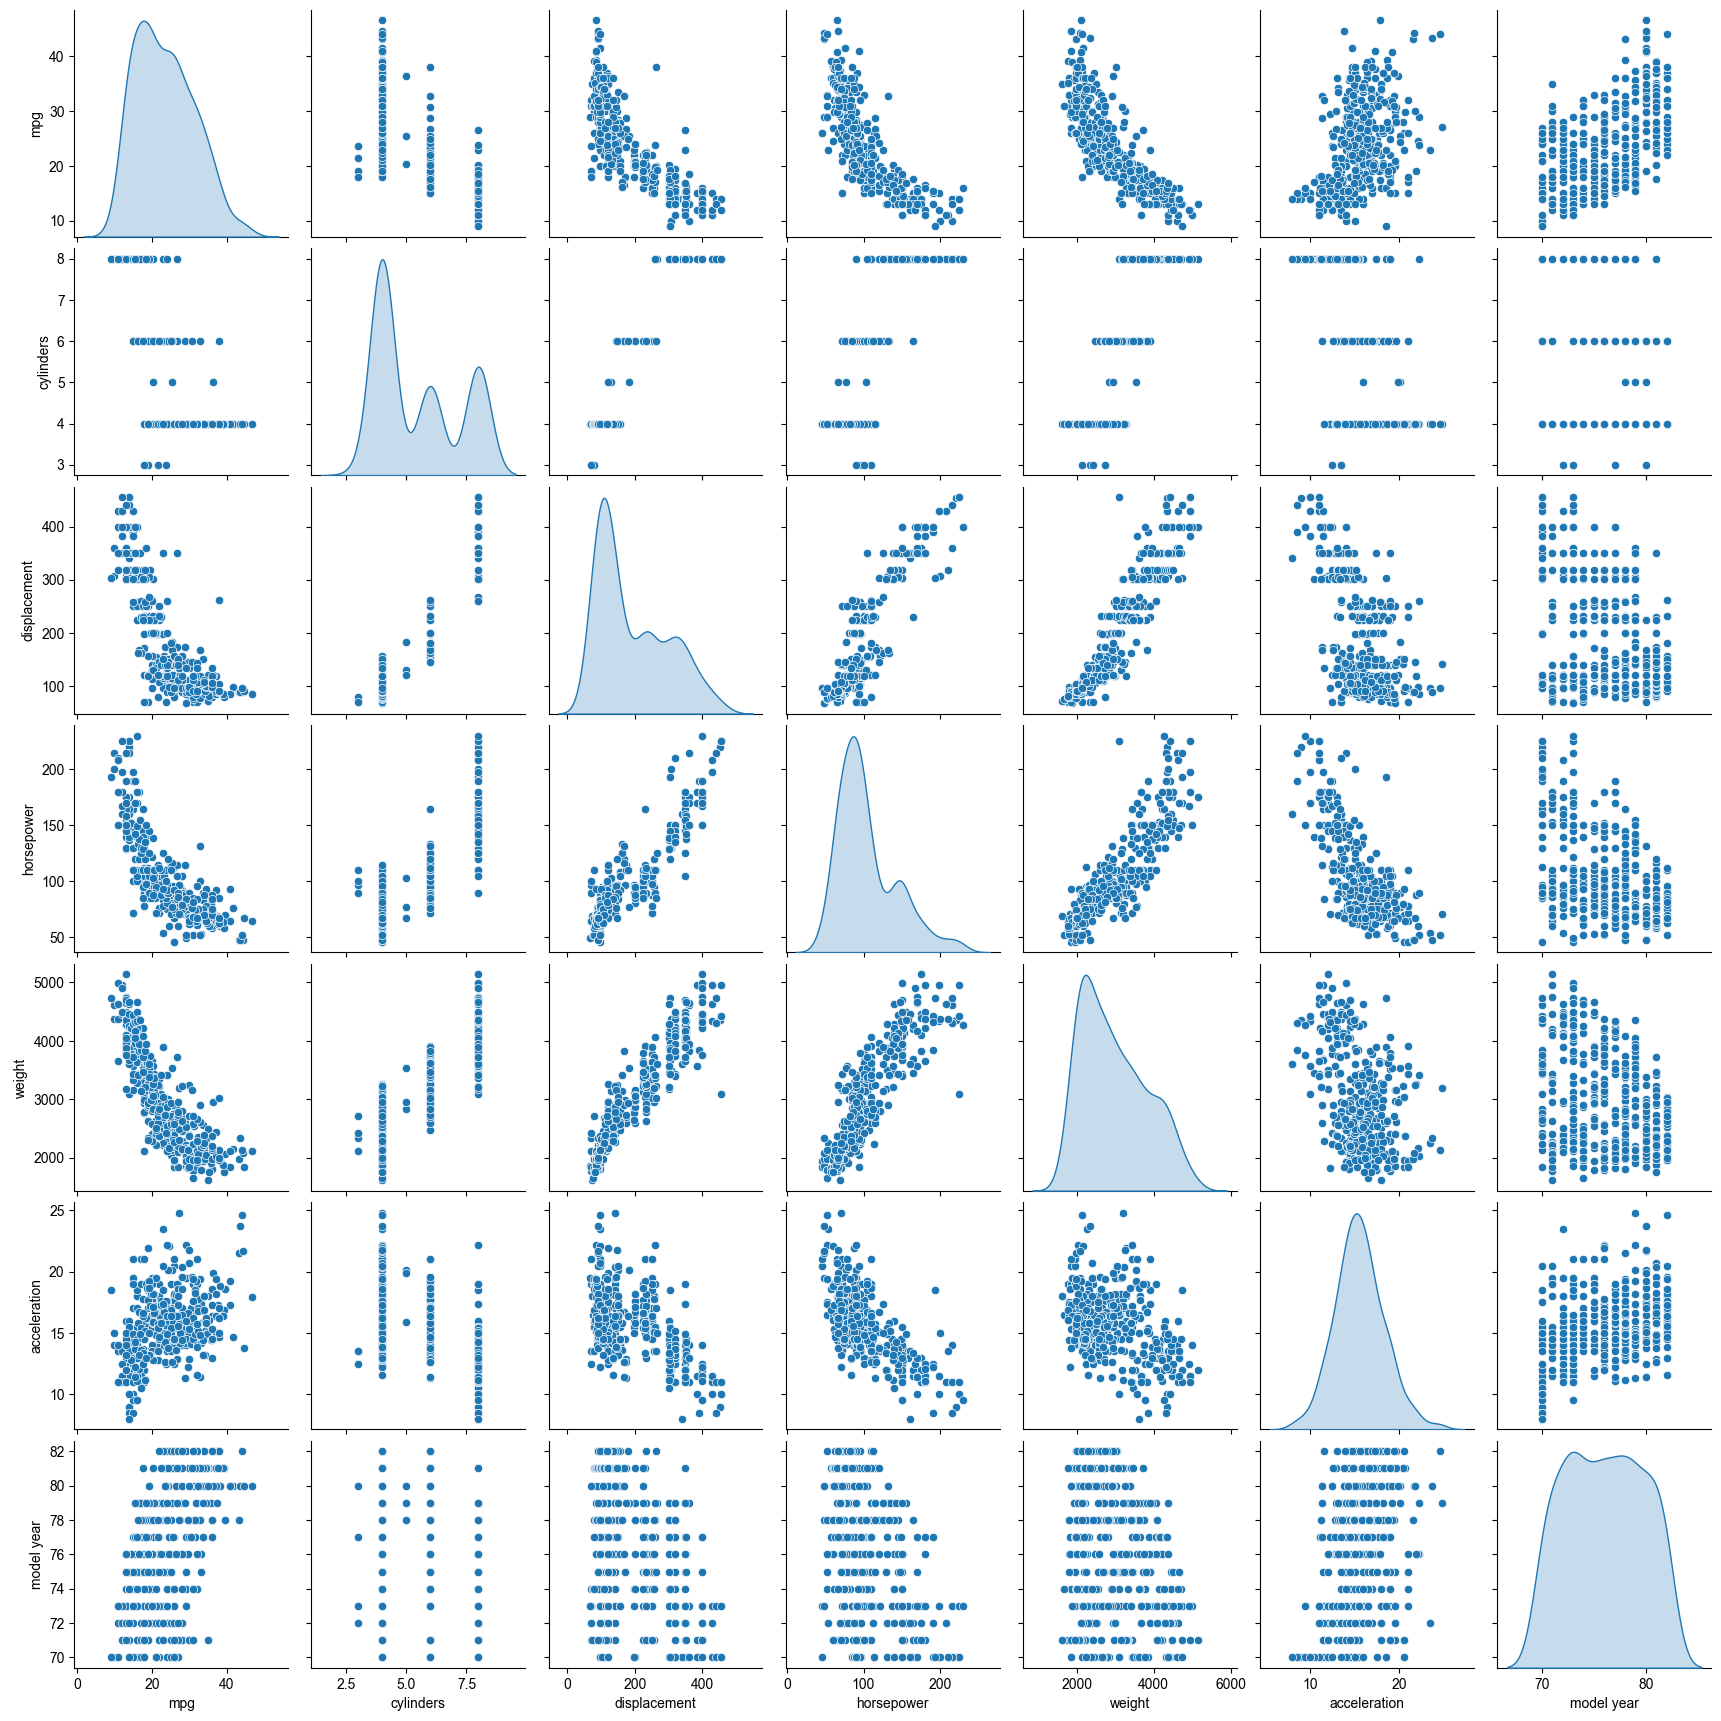

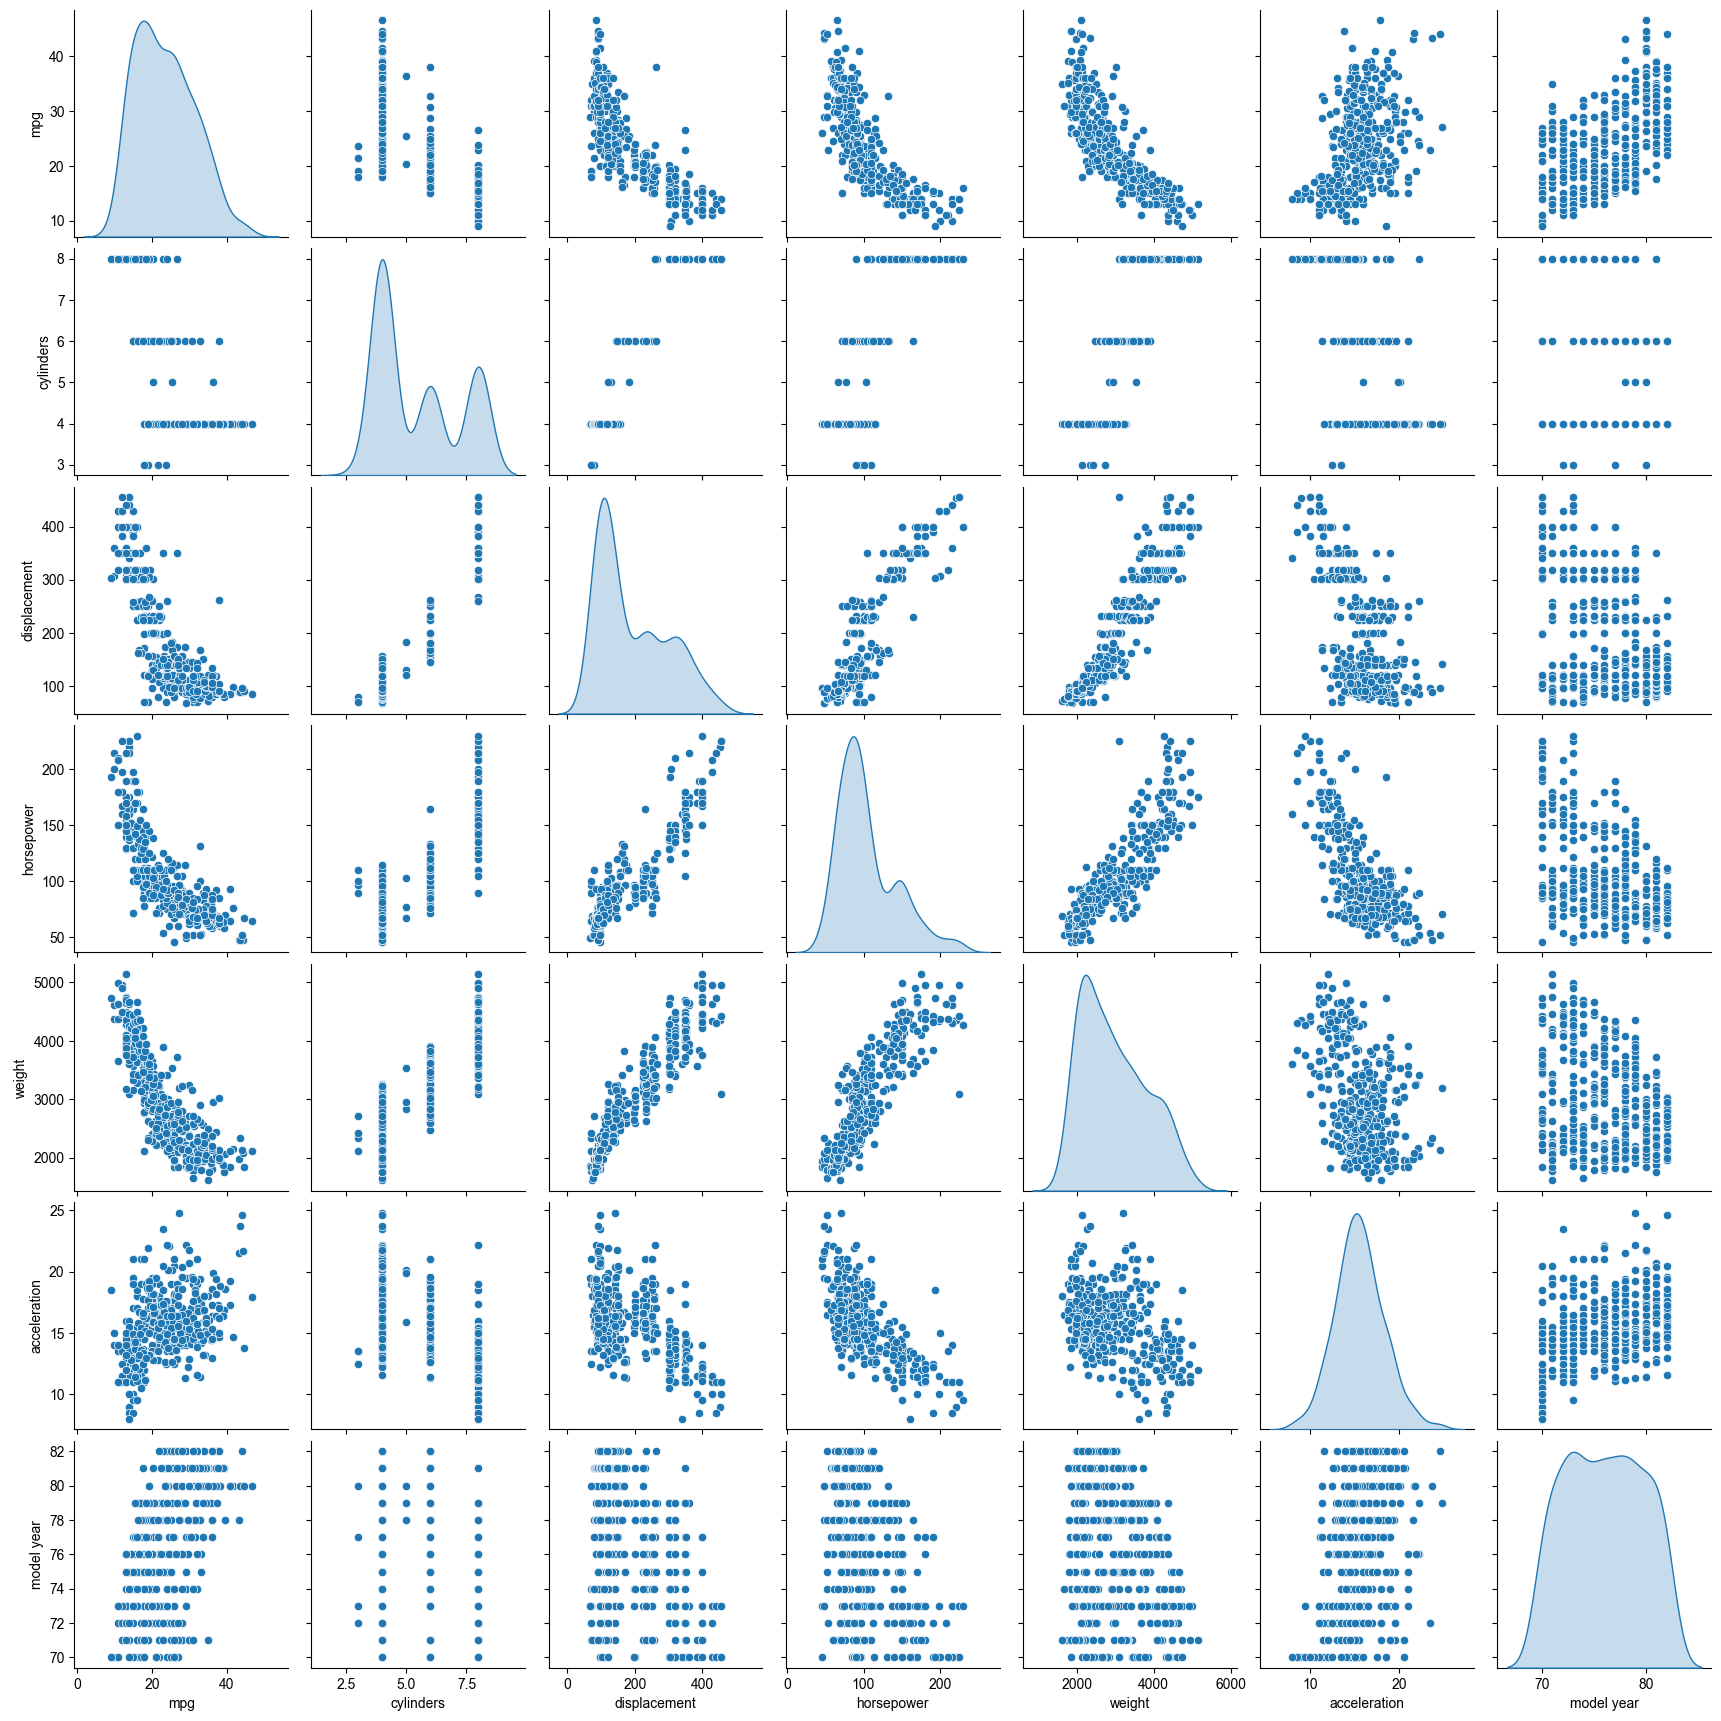

<Figure size 1200x1000 with 0 Axes>

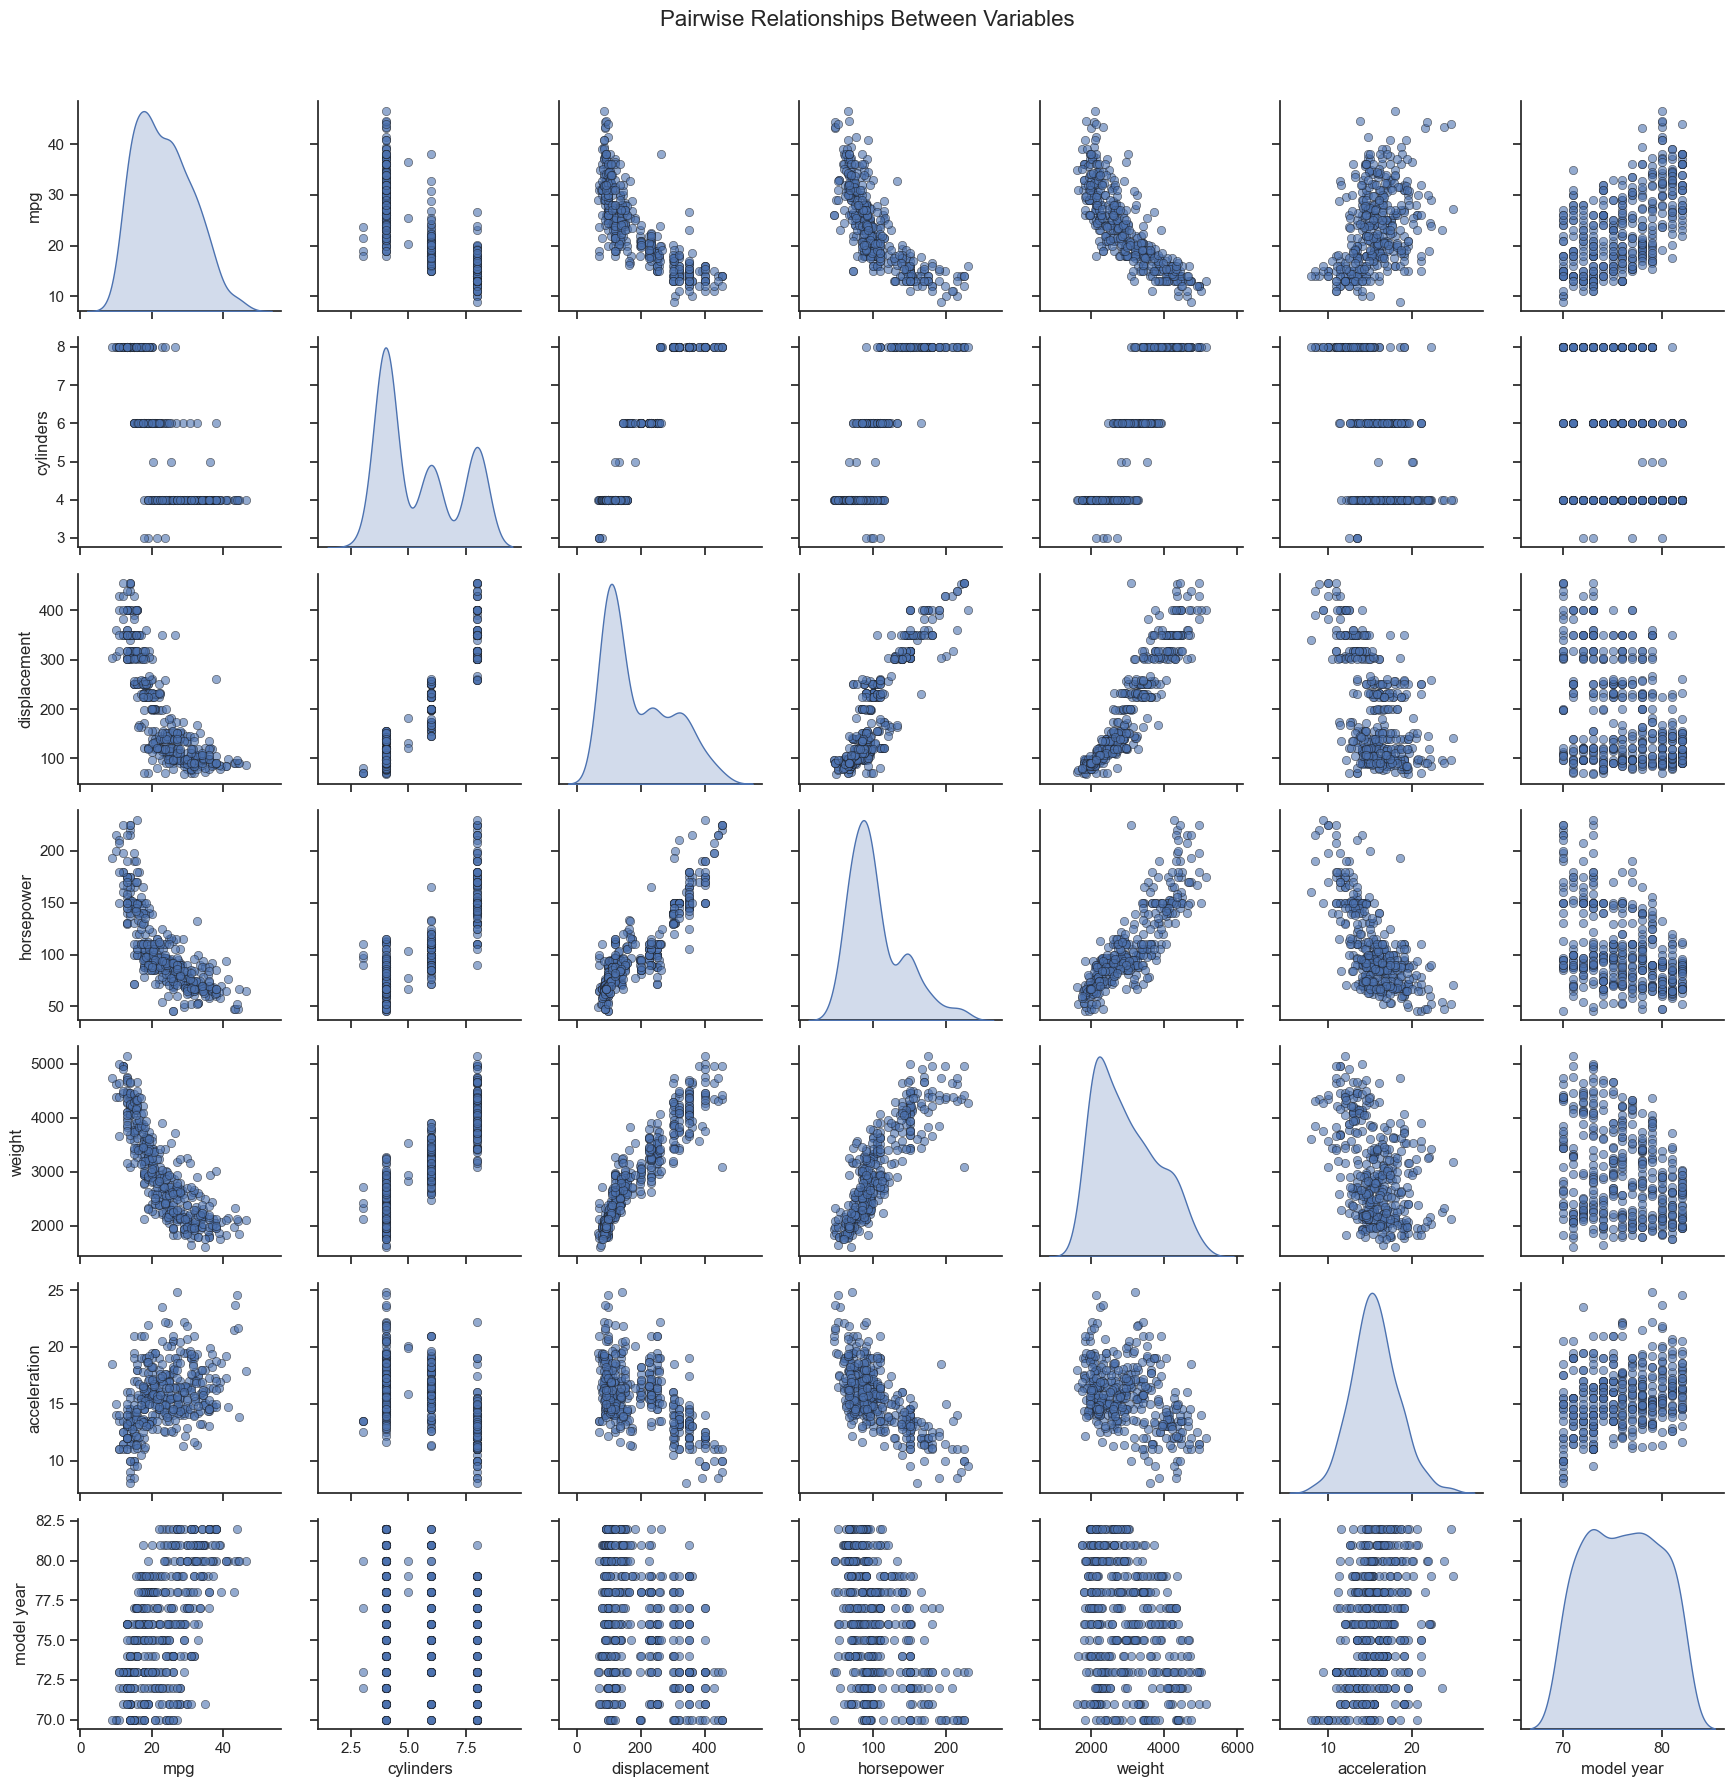

In [32]:
# Create a pairplot with seaborn to visualize relationships between variables
plt.figure(figsize=(12, 10))  # Set a specific figure size
sns.set(style="ticks")  # Set seaborn style

# Create the pairplot with enhanced visualization options
pairplot = sns.pairplot(data_attr, 
                       diag_kind='kde',
                       plot_kws={'alpha': 0.6, 'edgecolor': 'k', 'linewidth': 0.5},
                       diag_kws={'shade': True})

# Improve the appearance of the plot
pairplot.fig.suptitle('Pairwise Relationships Between Variables', y=1.02, fontsize=16)

# Make sure plot is displayed
plt.tight_layout()
plt.show()

Observation between 'mpg' and other attributes indicate the relationship is not really linear. However, the plots also indicate that linearity would still capture quite a bit of useful information/pattern. Several assumptions of classical linear regression seem to be violated, including the assumption of no Heteroscedasticity


## Split Data

In [34]:
# lets build our linear model
# independant variables
X = data.drop(columns = {'mpg'})
# the dependent variable
y = data['mpg']

In [35]:
# Sklearn package's model_selection have a function train_test_split() is used for data splitting into test(out of sample) and train dataset
from sklearn.model_selection import train_test_split


# Split X and y into training and test set(out of sample data) in 70:30 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

### Q.3 & 4 Create linear regression model using statsmodels OLS and interpretate coefficient

In [80]:
# import libraries for building linear regression model
#using statsmodel

from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.formula.api import ols
import statsmodels.api as sm


# let's add the intercept to data
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

# Create the model
model1 = sm.OLS(y_train, X_train_ols).fit()
# get the model summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     180.3
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           1.46e-91
Time:                        16:07:44   Log-Likelihood:                -744.60
No. Observations:                 278   AIC:                             1503.
Df Residuals:                     271   BIC:                             1529.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -15.6217      5.694     -2.743   

- Not all the variables are statistically significant to predict the outcome variable. To check which are statistically significant or have predictive power to predict the target variable, we need to check the `p-value` against all the independent variables.
- **Interpreting the Regression Results:**

1. **Adjusted. R-squared**: It reflects the fit of the model.
    - R-squared values range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
    
2. **coeff**: It represents the change in the output Y due to a change of one unit in the variable (everything else held constant).
3. **std err**: It reflects the level of accuracy of the coefficients.
    - The lower it is, the more accurate the coefficients are.
4. **P >|t|**: It is p-value.
   
   * Pr(>|t|) : For each independent feature there is a null hypothesis and alternate hypothesis 

    Ho : Independent feature is not significant 
   
    Ha : Independent feature is significant 
    
   * A p-value of less than 0.05 is considered to be statistically significant.

   
5. **Confidence Interval**: It represents the range in which our coefficients are likely to fall (with a likelihood of 95%).

* To be able to make statistical inferences from our model, **we will have to test the significance of the regression coefficients and linear regression assumptions.**

### Checking the performance of the model on the train and test data set

Features with significance level (α = 0.05):
                   Feature       p-value  Significant
const                const  6.487271e-03         True
cylinders        cylinders  6.765586e-01        False
displacement  displacement  2.530530e-01        False
horsepower      horsepower  5.886985e-01        False
weight              weight  4.175711e-15         True
acceleration  acceleration  8.111306e-01        False
model year      model year  4.888344e-28         True

Features that are NOT statistically significant:
                   Feature   p-value  Significant
cylinders        cylinders  0.676559        False
displacement  displacement  0.253053        False
horsepower      horsepower  0.588699        False
acceleration  acceleration  0.811131        False


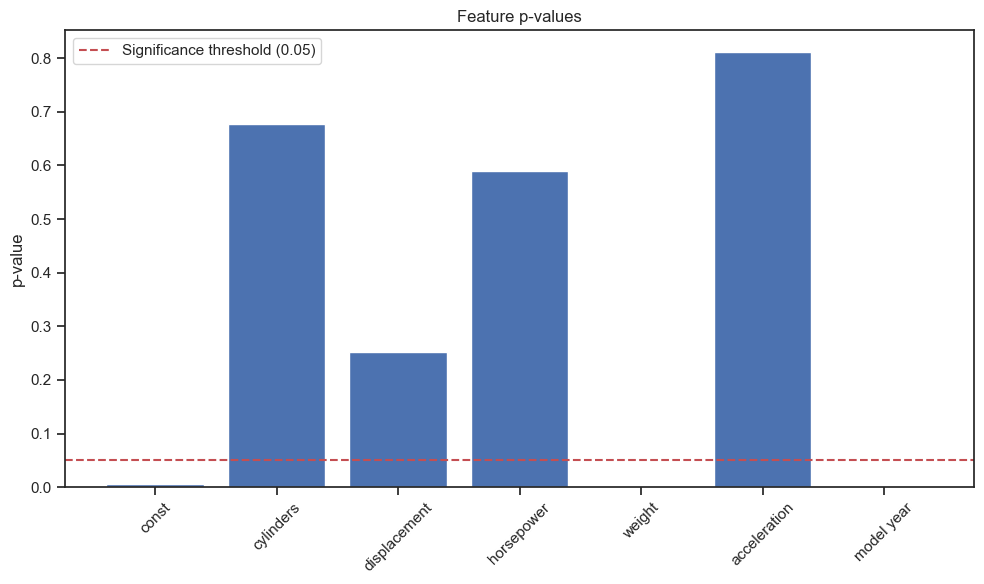

In [41]:
# Extract p-values from the model summary
p_values = model1.pvalues

# Display features with their p-values
feature_significance = pd.DataFrame({
    'Feature': p_values.index,
    'p-value': p_values.values,
    'Significant': p_values < 0.05
})

print("Features with significance level (α = 0.05):")
print(feature_significance)

print("\nFeatures that are NOT statistically significant:")
insignificant_features = feature_significance[feature_significance['p-value'] >= 0.05]
print(insignificant_features)

# Visualize p-values
plt.figure(figsize=(10, 6))
plt.bar(feature_significance['Feature'], feature_significance['p-value'])
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance threshold (0.05)')
plt.xticks(rotation=45)
plt.title('Feature p-values')
plt.ylabel('p-value')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref(olsmodel, x_train, x_test, y_train,y_test):

    # Insample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train, y_observed_train),
                    rmse(y_pred_test, y_observed_test),
                ],
                "MAE": [
                    mae(y_pred_train, y_observed_train),
                    mae(y_pred_test, y_observed_test),
                ],
                "MAPE": [
                    mape(y_pred_train, y_observed_train),
                    mape(y_pred_test, y_observed_test),
                ],
            }
        )
    )


# Checking model performance
model_pref(model1, X_train_ols, X_test_ols,y_train,y_test)  

    Data      RMSE       MAE       MAPE
0  Train  3.523532  2.729873  12.714357
1   Test  3.182169  2.479904  11.634185


**Observations:**

* RMSE, MAE, and MAPE of train and test data are not very different, indicating that the **model is not overfitting and has generalized well.**

### Question 5: Performing cross validation and comparing its average performance to OLS performance

In [43]:
# import the required function
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# build the regression model using Sklearn Linear regression
linearregression = LinearRegression()                                    

cv_Score11 = cross_val_score(linearregression, X_train, y_train, cv = 10)
cv_Score12 = cross_val_score(linearregression, X_train, y_train, cv = 10, 
                             scoring = 'neg_mean_squared_error')                                  

print("RSquared: %0.3f (+/- %0.3f)" % (cv_Score11.mean(), cv_Score11.std() * 2))
print("Mean Squared Error: %0.3f (+/- %0.3f)" % (-1*cv_Score12.mean(), cv_Score12.std() * 2))

RSquared: 0.784 (+/- 0.076)
Mean Squared Error: 13.116 (+/- 6.706)


### Get model Coefficients in a pandas dataframe with column 'Feature' having all the features and column 'Coefs' with all the corresponding Coefs. Write the regression equation.

In [46]:
coef = model1.params
coef

const          -15.621708
cylinders       -0.180958
displacement     0.010984
horsepower      -0.008983
weight          -0.007188
acceleration     0.029143
model year       0.788357
dtype: float64

In [47]:
# Let us write the equation of the fit
Equation = "log (car_mileage) ="
print(Equation, end='\t')
for i in range(len(coef)):
    print('(', coef[i], ') * ', coef.index[i], '+', end = ' ')

log (car_mileage) =	( -15.621707993406707 ) *  const + ( -0.1809580503230582 ) *  cylinders + ( 0.01098367998775471 ) *  displacement + ( -0.008982747488096549 ) *  horsepower + ( -0.0071881903327706545 ) *  weight + ( 0.02914290133876296 ) *  acceleration + ( 0.7883566858707737 ) *  model year + 

/var/folders/wy/bkmn6g6d7l70zk01gf49xkl00000gn/T/ipykernel_6168/1038366294.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('(', coef[i], ') * ', coef.index[i], '+', end = ' ')


### Building Decision Tree

In [48]:
#importing Decision tree regressor using sklearn

from sklearn.tree import DecisionTreeRegressor

In [50]:
# splitting the data in 70:30 ratio of train to test data
# separate the dependent and indepedent variable
Y1 = data['mpg']
X1 = data.drop(columns = {'mpg'})
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, Y1, test_size=0.30 , random_state=1)

### Question 6: Building Decision tree and Checking its performance

In [51]:
#defining the Descision tree regressor
#remove ________ and define decision tree and complete the code
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state = 1)

#Fitting Descision Tree regressor to train dataset
#remove ________ and fit decision tree and complete the code
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

Checking model perform on the train and test dataset

In [52]:
model_pref(dt, X_train1, X_test1,y_train1,y_test1)  

    Data      RMSE    MAE       MAPE
0  Train  0.000000  0.000   0.000000
1   Test  4.167033  2.745  11.814997


**Observations:**

- **The model seem to overfit the data** as rmse, mae and mape value of train data is 0, but that value for test data is much higher.

In [53]:
from sklearn.tree import plot_tree

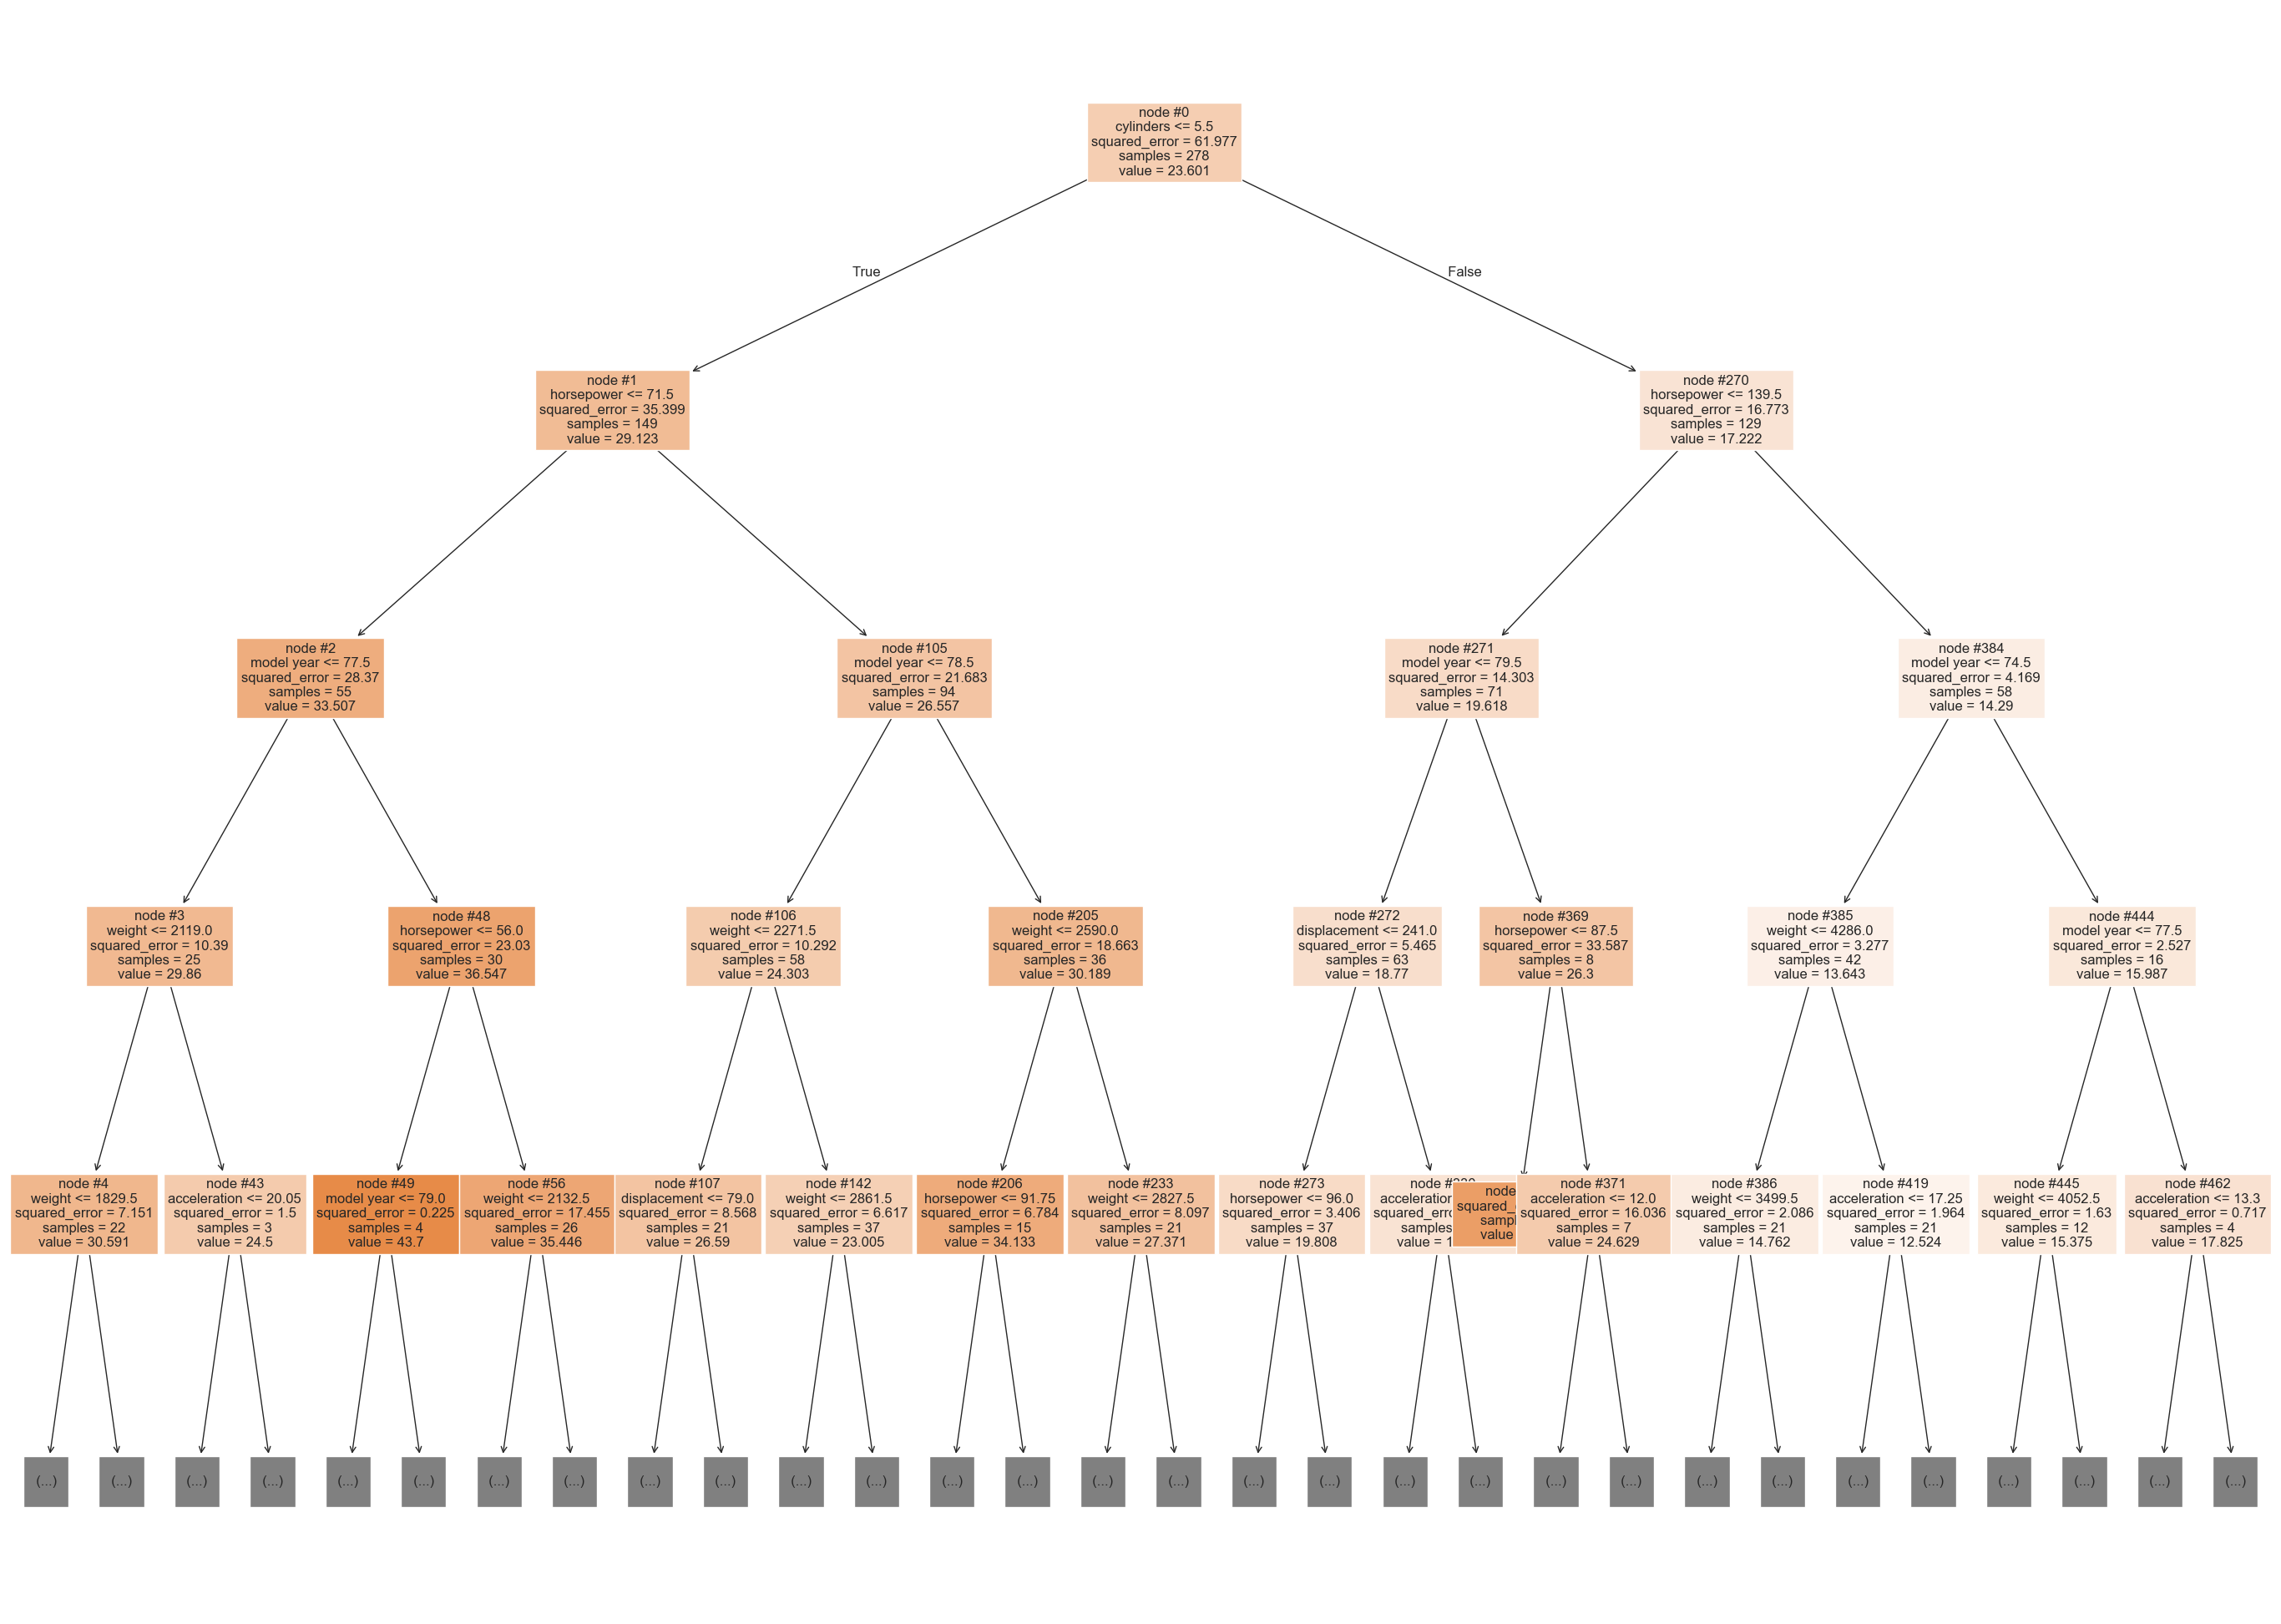

In [54]:
features = list(X1.columns)

plt.figure(figsize=(35,25))
plot_tree(dt, max_depth=4, feature_names=features,filled=True,fontsize=12,node_ids=True,class_names=True)
plt.show()

#### Let's plot the feature importance for each variable in the dataset and analyze the variables

### Checking Feature importance

<Figure size 800x400 with 0 Axes>

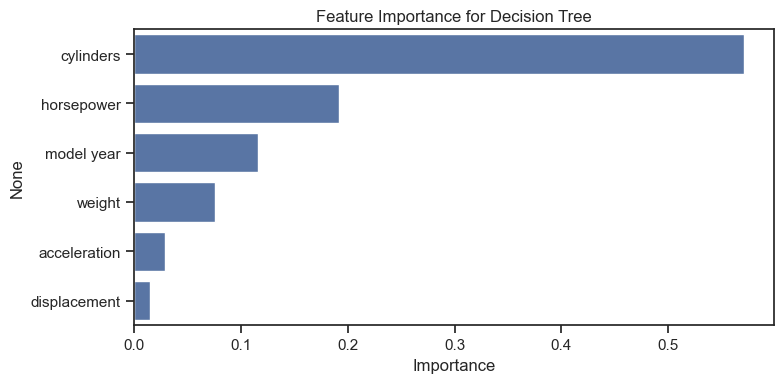

In [57]:
#find feature importance for decision tree

importances = dt.feature_importances_


columns=X1.columns
importance_df=pd.DataFrame(importances,index=columns,columns=['Importance']).sort_values(by='Importance',ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y=importance_df.index, data=importance_df)
plt.title('Feature Importance for Decision Tree')
plt.tight_layout()
plt.show()

### Building Random Forest

In [58]:
#importing random forest regressor usinf sklearn

from sklearn.ensemble import RandomForestRegressor

#### Parameters for regression
**n_estimators**: The number of trees in the forest.

**min_samples_split**: The minimum number of samples required to split an internal node:

**max_depth**
The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

**max_features{“auto”, “sqrt”, “log2”, 'None'}**: The number of features to consider when looking for the best split.

- If “auto”, then max_features=sqrt(n_features).

- If “sqrt”, then max_features=sqrt(n_features) (same as “auto”).

- If “log2”, then max_features=log2(n_features).

- If None, then max_features=n_features.

In [61]:
#defining the Random forest regressor
#remove ________ and define random forest tree and complete the code
rf = RandomForestRegressor(random_state = 1)

#Hyperparameters, we have randomly choosen them for now but we can tune these hyperparameters and get the best model. 

#fitting the model
#remove ________ and fit random forest tree and complete the code
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=1)

### Q.7 Check performance of Random Forest

In [62]:
# checking model performance on test dataset
rf.score(X_test1, y_test1)

# checking model performance on test dataset
model_pref(rf, X_train1, X_test1,y_train1,y_test1)
# find feature importance for random forest
importances = rf.feature_importances_
columns=X1.columns

    Data      RMSE       MAE      MAPE
0  Train  1.037804  0.726061  3.084414
1   Test  2.787584  1.983983  8.626681


In [ ]:
model_pref(rf, X_train1, X_test1,y_train1,y_test1)  

### Question 8 & 9: Checking the feature importance of each variable in Random Forest and comparing to Decision Tree

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

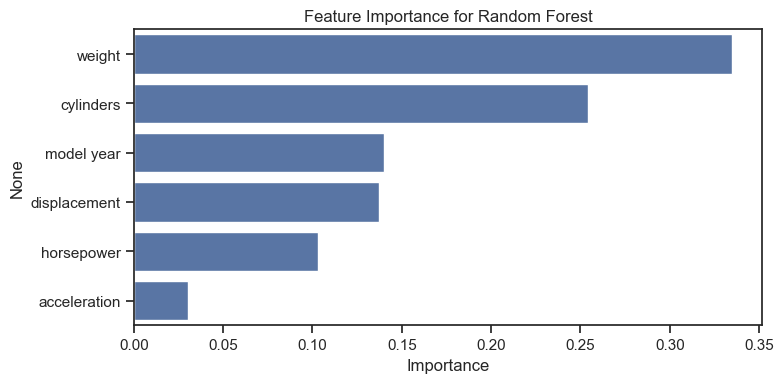

In [66]:
#remove ________ and print feature importance Random forest and complete the code
importances = rf.feature_importances_

columns=X1.columns
importance_df=pd.DataFrame(importances,index=columns,columns=['Importance']).sort_values(by='Importance',ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=importance_df['Importance'], y=importance_df.index)
plt.title('Feature Importance for Random Forest')
plt.tight_layout()
plt.show()

### Question 10: Comparing results of three model

In [67]:
print("Linear Regression")
model_pref(model1, X_train_ols, X_test_ols,y_train,y_test)
print("Decision tree")
model_pref(dt, X_train1, X_test1,y_train1,y_test1)
print("Random Forest")
model_pref(rf, X_train1, X_test1,y_train1,y_test1)  

Linear Regression
    Data      RMSE       MAE       MAPE
0  Train  3.523532  2.729873  12.714357
1   Test  3.182169  2.479904  11.634185
Decision tree
    Data      RMSE    MAE       MAPE
0  Train  0.000000  0.000   0.000000
1   Test  4.167033  2.745  11.814997
Random Forest
    Data      RMSE       MAE      MAPE
0  Train  1.037804  0.726061  3.084414
1   Test  2.787584  1.983983  8.626681


,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,Train-Test R² Difference
Linear Regression,0.8,0.827,3.524,3.182,2.73,2.48,-0.027
Decision Tree,1.0,0.703,0.0,4.167,0.0,2.745,0.297
Random Forest,0.983,0.867,1.038,2.788,0.726,1.984,0.116


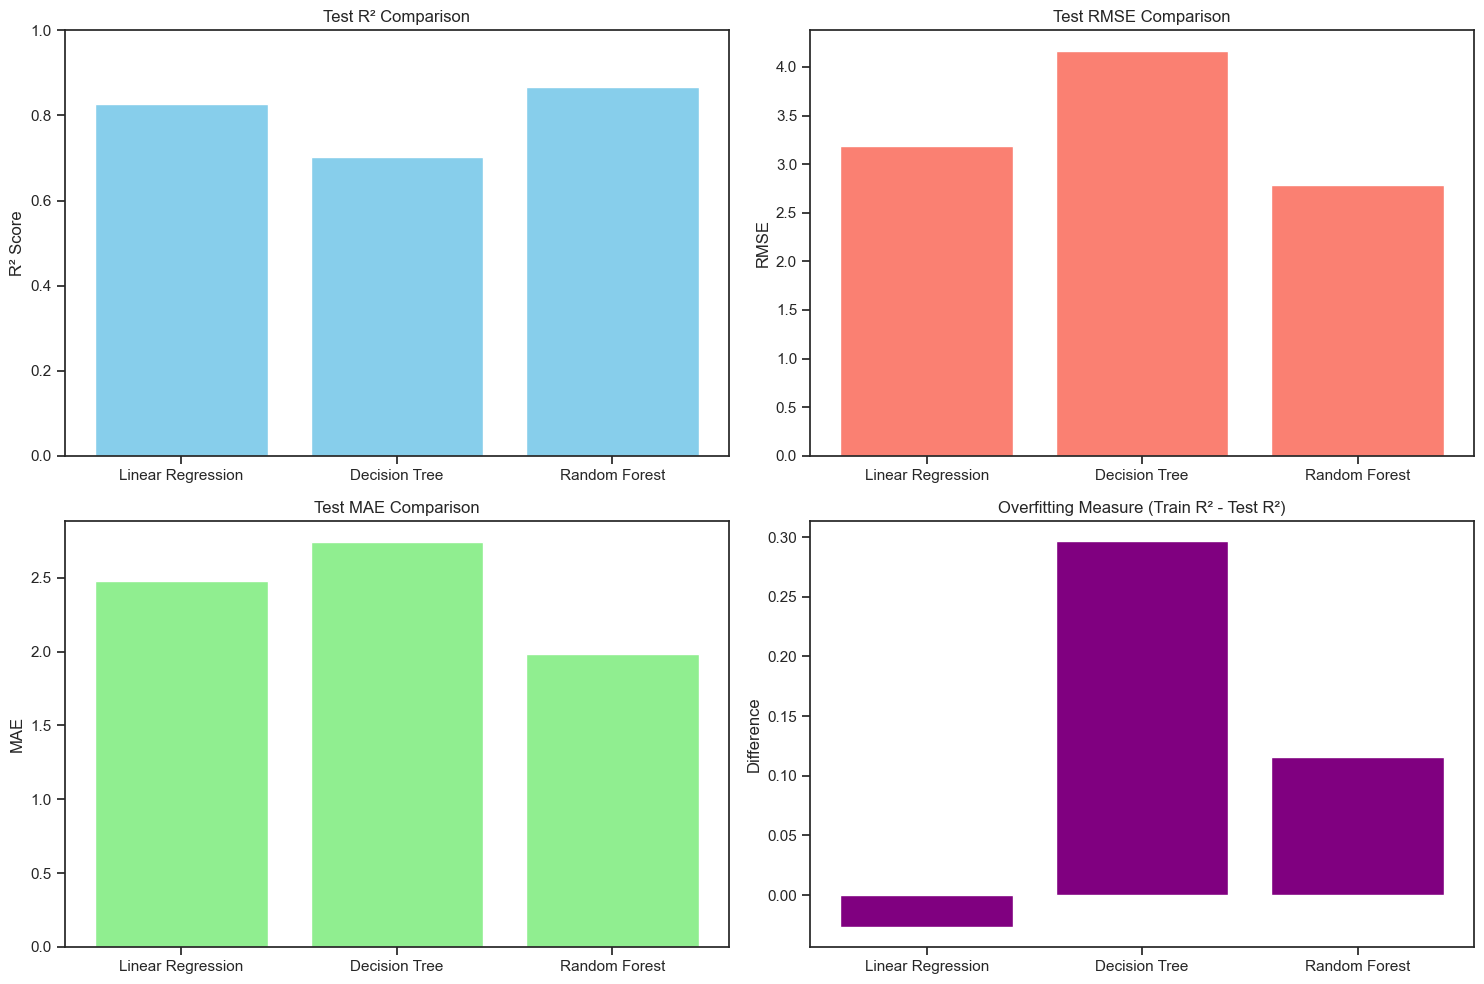

Model Performance Analysis:
--------------------------
Best model based on Test R²: Random Forest with R² = 0.867
Best model based on Test RMSE: Random Forest with RMSE = 2.788
Best model based on Test MAE: Random Forest with MAE = 1.984
Least overfitting model (smallest Train-Test R² difference): Linear Regression with difference = -0.027

Conclusion:
Random Forest performs best overall because it balances model complexity with generalization ability.
It offers the highest test R² while maintaining a reasonable level of model complexity compared to Decision Trees.
Random Forests reduce overfitting by averaging multiple decision trees, making predictions more robust.


In [68]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Compare models and analyze their performance

# Create a comparison dataframe

# Get predictions from each model
lin_train_pred = model1.predict(X_train_ols)
lin_test_pred = model1.predict(X_test_ols)

dt_train_pred = dt.predict(X_train1)
dt_test_pred = dt.predict(X_test1)

rf_train_pred = rf.predict(X_train1)
rf_test_pred = rf.predict(X_test1)

# Create a comparison dataframe
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
metrics = ['Train R²', 'Test R²', 'Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train-Test R² Difference']

results = pd.DataFrame(index=models, columns=metrics)

# Calculate metrics
results.loc['Linear Regression'] = [
    r2_score(y_train, lin_train_pred),
    r2_score(y_test, lin_test_pred),
    np.sqrt(mean_squared_error(y_train, lin_train_pred)),
    np.sqrt(mean_squared_error(y_test, lin_test_pred)),
    mean_absolute_error(y_train, lin_train_pred),
    mean_absolute_error(y_test, lin_test_pred),
    r2_score(y_train, lin_train_pred) - r2_score(y_test, lin_test_pred)
]

results.loc['Decision Tree'] = [
    r2_score(y_train1, dt_train_pred),
    r2_score(y_test1, dt_test_pred),
    np.sqrt(mean_squared_error(y_train1, dt_train_pred)),
    np.sqrt(mean_squared_error(y_test1, dt_test_pred)),
    mean_absolute_error(y_train1, dt_train_pred),
    mean_absolute_error(y_test1, dt_test_pred),
    r2_score(y_train1, dt_train_pred) - r2_score(y_test1, dt_test_pred)
]

results.loc['Random Forest'] = [
    r2_score(y_train1, rf_train_pred),
    r2_score(y_test1, rf_test_pred),
    np.sqrt(mean_squared_error(y_train1, rf_train_pred)),
    np.sqrt(mean_squared_error(y_test1, rf_test_pred)),
    mean_absolute_error(y_train1, rf_train_pred),
    mean_absolute_error(y_test1, rf_test_pred),
    r2_score(y_train1, rf_train_pred) - r2_score(y_test1, rf_test_pred)
]

# Format the results for better readability
pd.set_option('display.precision', 3)
display(results)

# Visualize the comparison
plt.figure(figsize=(15, 10))

# R-squared comparison
plt.subplot(2, 2, 1)
plt.bar(models, results['Test R²'], color='skyblue')
plt.title('Test R² Comparison')
plt.ylabel('R² Score')
plt.ylim(0, 1)

# RMSE comparison
plt.subplot(2, 2, 2)
plt.bar(models, results['Test RMSE'], color='salmon')
plt.title('Test RMSE Comparison')
plt.ylabel('RMSE')

# MAE comparison
plt.subplot(2, 2, 3)
plt.bar(models, results['Test MAE'], color='lightgreen')
plt.title('Test MAE Comparison')
plt.ylabel('MAE')

# Overfitting comparison (difference between train and test R²)
plt.subplot(2, 2, 4)
plt.bar(models, results['Train-Test R² Difference'], color='purple')
plt.title('Overfitting Measure (Train R² - Test R²)')
plt.ylabel('Difference')

plt.tight_layout()
plt.show()

# Analysis of results
print("Model Performance Analysis:")
print("--------------------------")
print(f"Best model based on Test R²: {models[results['Test R²'].argmax()]} with R² = {results['Test R²'].max():.3f}")
print(f"Best model based on Test RMSE: {models[results['Test RMSE'].argmin()]} with RMSE = {results['Test RMSE'].min():.3f}")
print(f"Best model based on Test MAE: {models[results['Test MAE'].argmin()]} with MAE = {results['Test MAE'].min():.3f}")
print(f"Least overfitting model (smallest Train-Test R² difference): {models[results['Train-Test R² Difference'].argmin()]} with difference = {results['Train-Test R² Difference'].min():.3f}")
print("\nConclusion:")
best_model = models[results['Test R²'].argmax()]
if best_model == 'Random Forest':
    print("Random Forest performs best overall because it balances model complexity with generalization ability.")
    print("It offers the highest test R² while maintaining a reasonable level of model complexity compared to Decision Trees.")
    print("Random Forests reduce overfitting by averaging multiple decision trees, making predictions more robust.")
elif best_model == 'Linear Regression':
    print("Linear Regression performs best overall because of its simplicity and good generalization ability.")
    print("It shows consistent performance between training and test data, indicating good model stability.")
    print("Linear models are more interpretable and less prone to overfitting with limited data.")
else:
    print("Decision Tree performs best but might be overfitting as indicated by the large difference between training and test performance.")
    print("This suggests that while it captures the training data patterns well, it may not generalize as effectively to new data.")